In [7]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import mlflow

sns.set_style("whitegrid")

PROJECT_ROOT = os.path.abspath("..")
DATA_PATH = os.path.join(PROJECT_ROOT, "data", "raw", "loan_approval_dataset.csv")

df = pd.read_csv(DATA_PATH)
df.head()

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected


In [3]:
target_col = "loan_status"
print("Shape:", df.shape)
print("\nColumns:\n", df.columns.tolist())
print("\nDtypes:\n", df.dtypes)

Shape: (4269, 13)

Columns:
 ['loan_id', ' no_of_dependents', ' education', ' self_employed', ' income_annum', ' loan_amount', ' loan_term', ' cibil_score', ' residential_assets_value', ' commercial_assets_value', ' luxury_assets_value', ' bank_asset_value', ' loan_status']

Dtypes:
 loan_id                       int64
 no_of_dependents             int64
 education                   object
 self_employed               object
 income_annum                 int64
 loan_amount                  int64
 loan_term                    int64
 cibil_score                  int64
 residential_assets_value     int64
 commercial_assets_value      int64
 luxury_assets_value          int64
 bank_asset_value             int64
 loan_status                 object
dtype: object


In [8]:
numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = df.select_dtypes(exclude=[np.number]).columns.tolist()

print("Numerical columns:", numerical_cols)
print("Categorical columns:", categorical_cols)

Numerical columns: ['loan_id', 'no_of_dependents', 'income_annum', 'loan_amount', 'loan_term', 'cibil_score', 'residential_assets_value', 'commercial_assets_value', 'luxury_assets_value', 'bank_asset_value']
Categorical columns: ['education', 'self_employed', 'loan_status']


In [9]:
if target_col in categorical_cols:
    categorical_cols.remove(target_col)

In [10]:
print(df[target_col].value_counts(dropna=False))
print(df[target_col].value_counts(normalize=True, dropna=False))

loan_status
Approved    2656
Rejected    1613
Name: count, dtype: int64
loan_status
Approved    0.62216
Rejected    0.37784
Name: proportion, dtype: float64


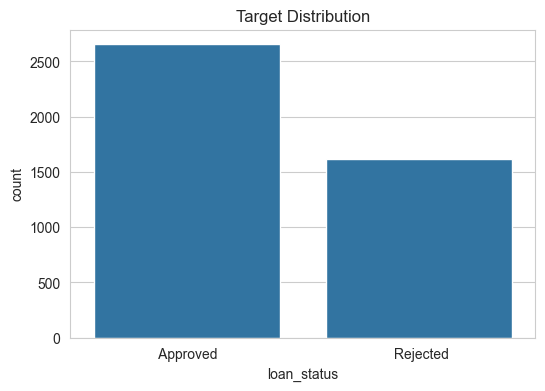

In [11]:
plt.figure(figsize=(6, 4))
sns.countplot(x=target_col, data=df)
plt.title("Target Distribution")
plt.show()

In [12]:
df[numerical_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
loan_id,4269.0,2.135000e+03,1.232498e+03,1.0,1068.0,2135.0,3202.0,4269.0
no_of_dependents,4269.0,2.498712e+00,1.695910e+00,0.0,1.0,3.0,4.0,5.0
income_annum,4269.0,5.059124e+06,2.806840e+06,200000.0,2700000.0,5100000.0,7500000.0,9900000.0
loan_amount,4269.0,1.513345e+07,9.043363e+06,300000.0,7700000.0,14500000.0,21500000.0,39500000.0
loan_term,4269.0,1.090045e+01,5.709187e+00,2.0,6.0,10.0,16.0,20.0
cibil_score,4269.0,5.999361e+02,1.724304e+02,300.0,453.0,600.0,748.0,900.0
residential_assets_value,4269.0,7.472617e+06,6.503637e+06,-100000.0,2200000.0,5600000.0,11300000.0,29100000.0
commercial_assets_value,4269.0,4.973155e+06,4.388966e+06,0.0,1300000.0,3700000.0,7600000.0,19400000.0
luxury_assets_value,4269.0,1.512631e+07,9.103754e+06,300000.0,7500000.0,14600000.0,21700000.0,39200000.0
bank_asset_value,4269.0,4.976692e+06,3.250185e+06,0.0,2300000.0,4600000.0,7100000.0,14700000.0


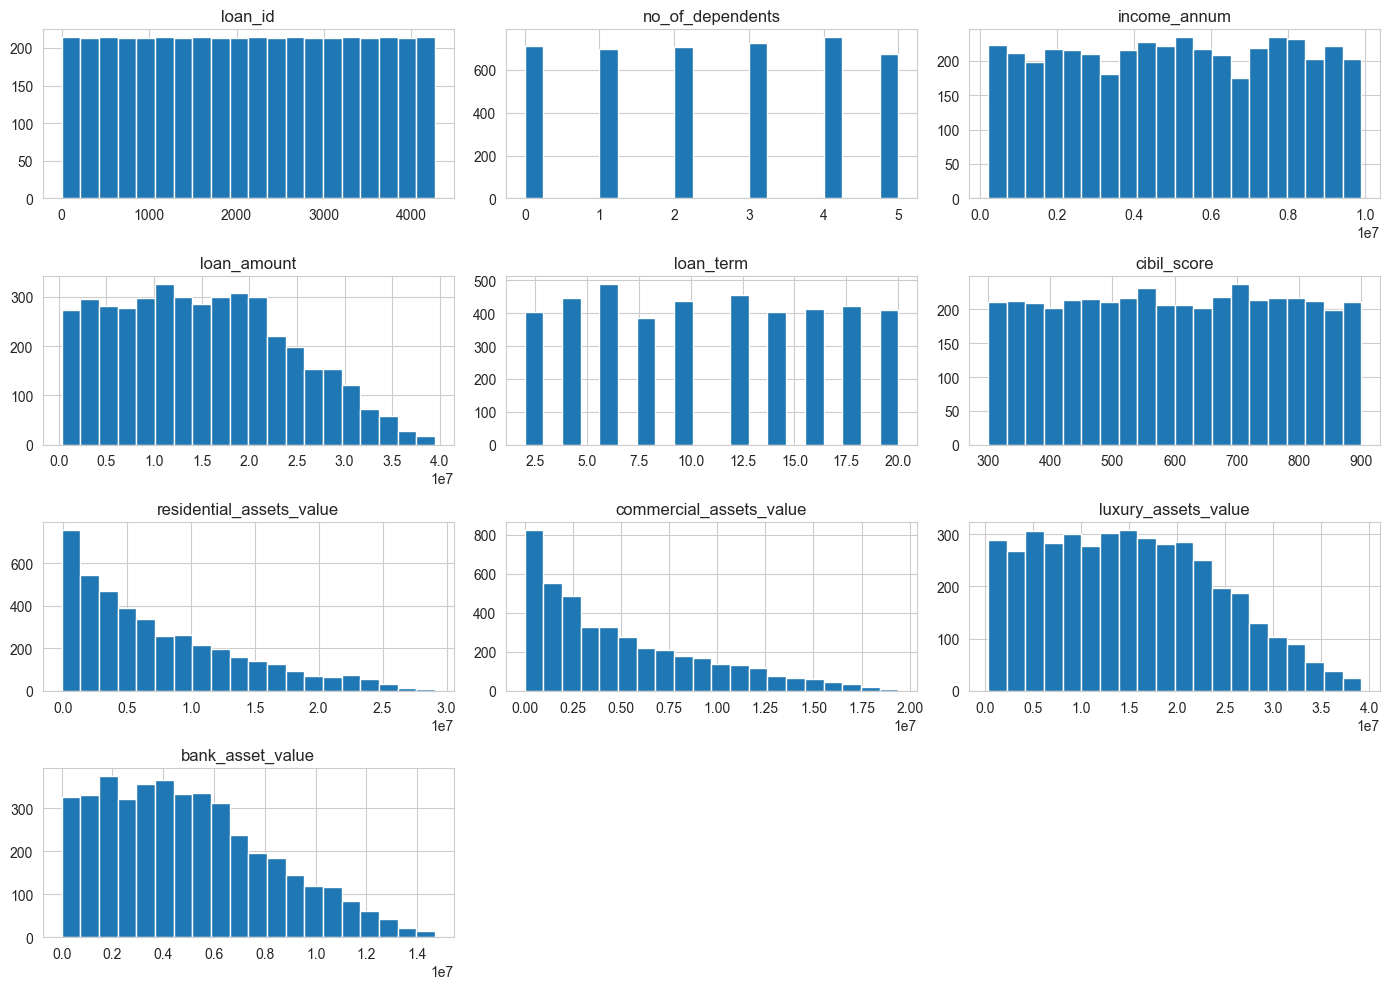

In [13]:
df[numerical_cols].hist(figsize=(14, 10), bins=20)
plt.tight_layout()
plt.show()

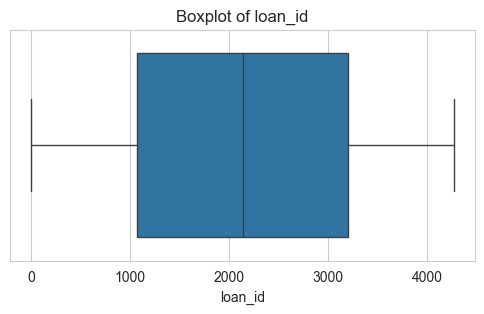

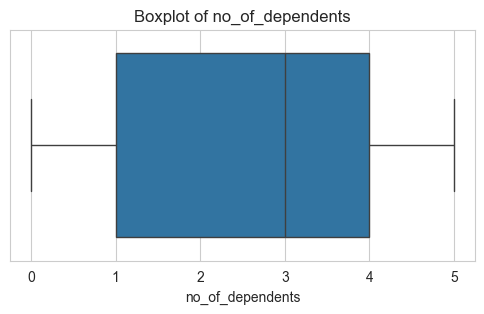

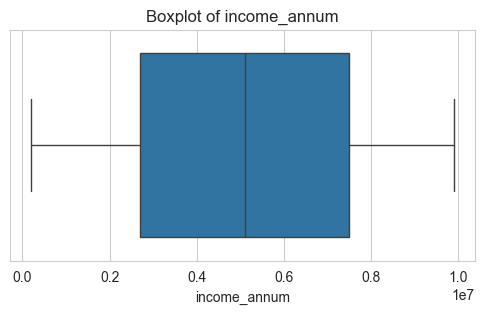

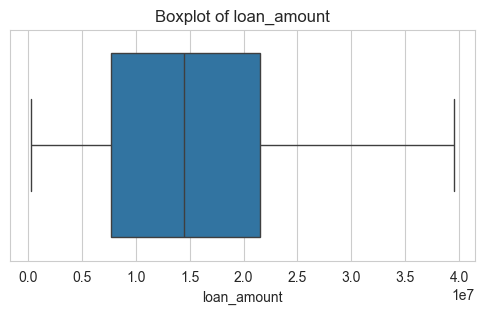

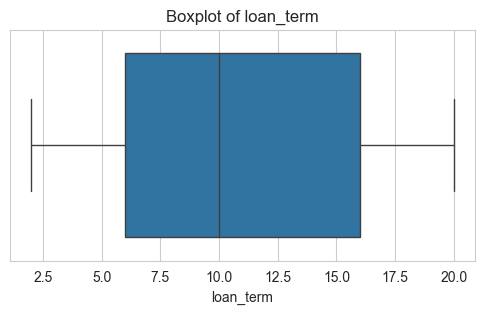

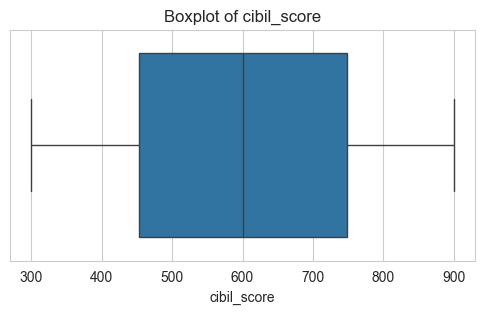

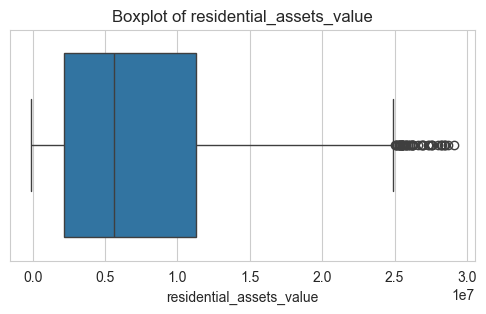

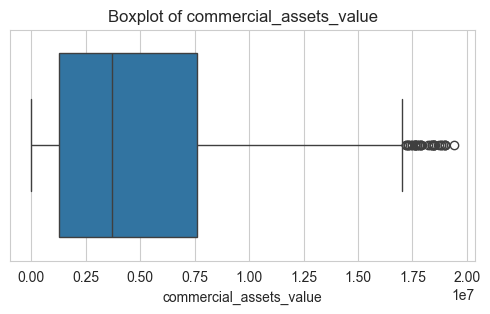

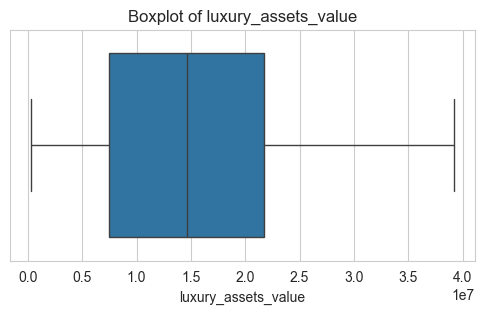

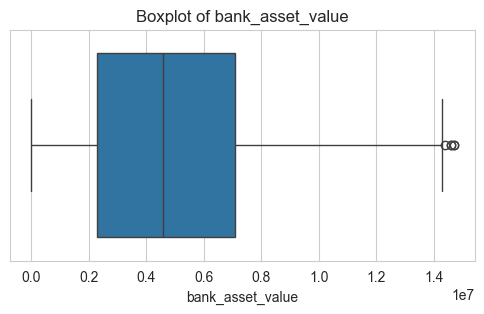

In [14]:
for col in numerical_cols:
    plt.figure(figsize=(6, 3))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

In [15]:
df[numerical_cols].skew().sort_values(ascending=False)

residential_assets_value    0.978451
commercial_assets_value     0.957791
bank_asset_value            0.560725
luxury_assets_value         0.322208
loan_amount                 0.308724
loan_term                   0.036359
loan_id                     0.000000
cibil_score                -0.009039
income_annum               -0.012814
no_of_dependents           -0.017971
dtype: float64

In [16]:
for col in categorical_cols:
    print(f"\nColumn: {col}")
    print(df[col].value_counts(dropna=False))


Column: education
education
Graduate        2144
Not Graduate    2125
Name: count, dtype: int64

Column: self_employed
self_employed
Yes    2150
No     2119
Name: count, dtype: int64


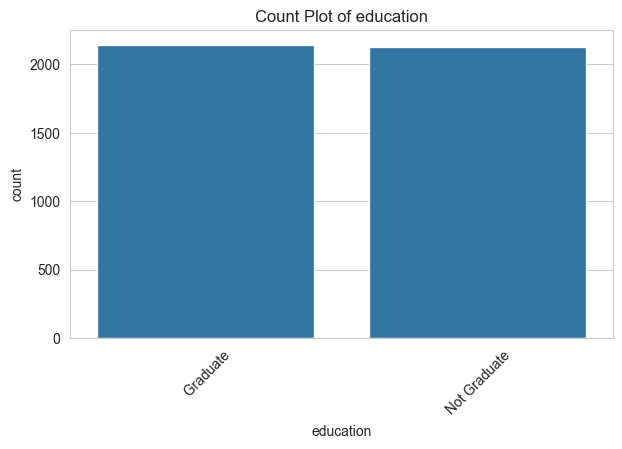

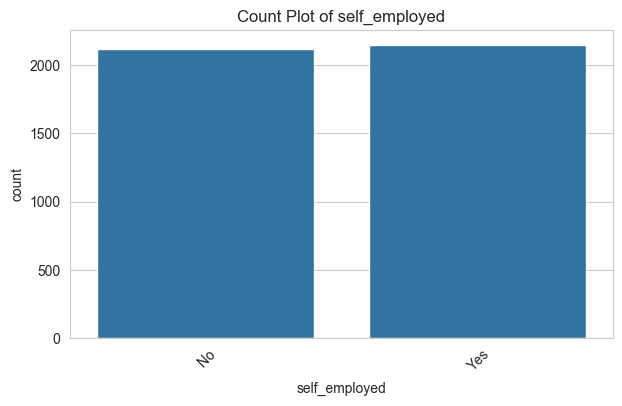

In [17]:
for col in categorical_cols:
    plt.figure(figsize=(7, 4))
    sns.countplot(x=col, data=df)
    plt.title(f"Count Plot of {col}")
    plt.xticks(rotation=45)
    plt.show()

In [18]:
df_eda = df.copy()
df_eda[target_col] = df_eda[target_col].map({"Y": 1, "N": 0})

ValueError: List of boxplot statistics and `positions` values must have same the length

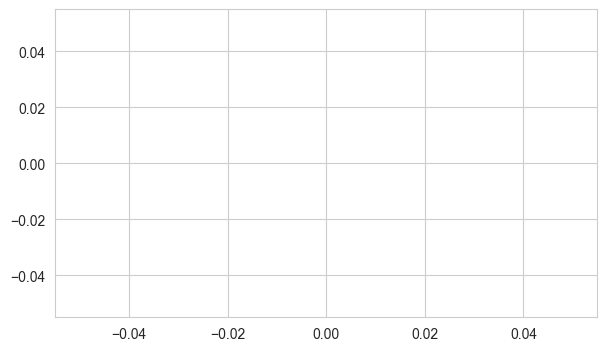

In [19]:
for col in numerical_cols:
    plt.figure(figsize=(7, 4))
    sns.boxplot(x=target_col, y=col, data=df_eda)
    plt.title(f"{col} vs {target_col}")
    plt.show()


Approval distribution by education
loan_status    Approved   Rejected
education                         
Graduate      62.453358  37.546642
Not Graduate  61.976471  38.023529


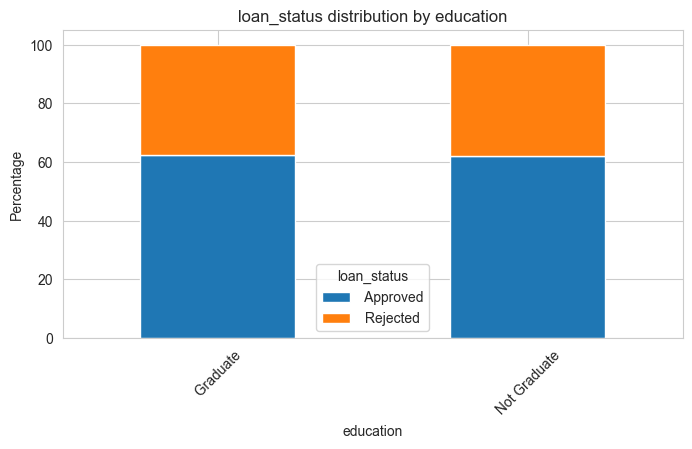


Approval distribution by self_employed
loan_status     Approved   Rejected
self_employed                      
No             62.199151  37.800849
Yes            62.232558  37.767442


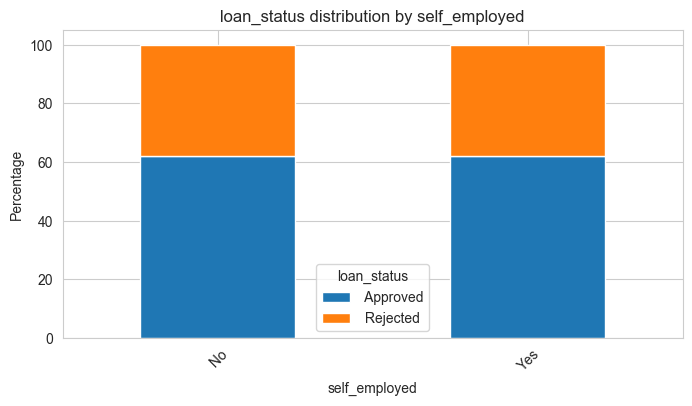

In [20]:
for col in categorical_cols:
    ct = pd.crosstab(df[col], df[target_col], normalize="index") * 100
    print(f"\nApproval distribution by {col}")
    print(ct)

    ct.plot(kind="bar", stacked=True, figsize=(8, 4))
    plt.title(f"{target_col} distribution by {col}")
    plt.ylabel("Percentage")
    plt.xticks(rotation=45)
    plt.show()

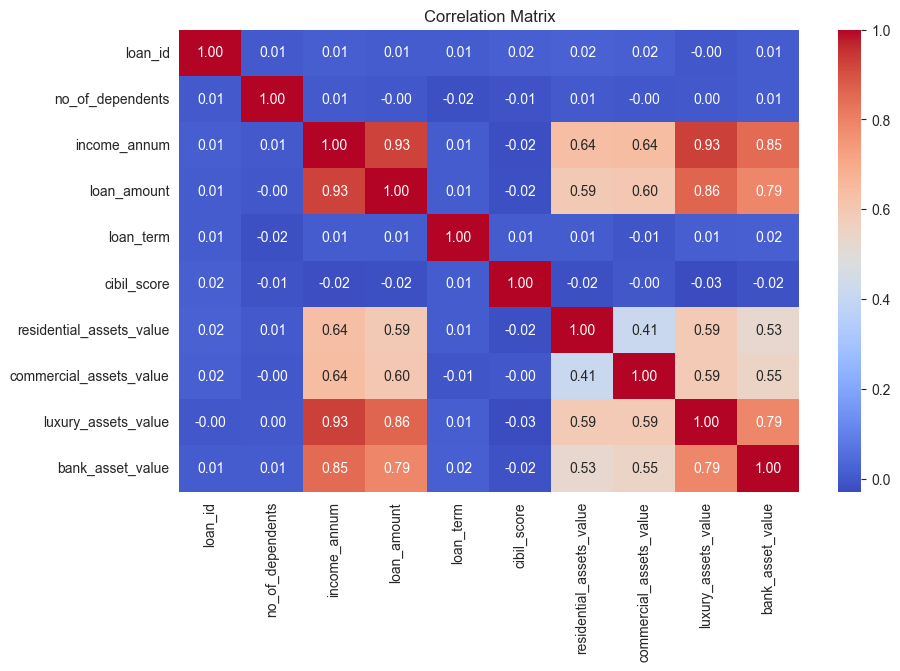

In [21]:
plt.figure(figsize=(10, 6))
corr = df[numerical_cols].corr()
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

In [22]:
mlflow.set_tracking_uri("file:../mlruns")
mlflow.set_experiment("loan_approval_phase2")

with mlflow.start_run(run_name="eda_summary"):
    mlflow.log_param("num_rows", df.shape[0])
    mlflow.log_param("num_columns", df.shape[1])
    mlflow.log_param("target_column", target_col)
    mlflow.log_param("num_numerical_cols", len(numerical_cols))
    mlflow.log_param("num_categorical_cols", len(categorical_cols))
    mlflow.log_metric("total_missing_values", int(df.isnull().sum().sum()))

/Users/pranavsrinivasvenkatesh/anaconda3/envs/multimodal_research/lib/python3.12/site-packages/mlflow/tracking/_tracking_service/utils.py:184: FutureWarning: The filesystem tracking backend (e.g., './mlruns') is deprecated as of February 2026. Consider transitioning to a database backend (e.g., 'sqlite:///mlflow.db') to take advantage of the latest MLflow features. See https://mlflow.org/docs/latest/self-hosting/migrate-from-file-store for migration guidance.
  return FileStore(store_uri, store_uri)
2026/04/01 22:01:25 INFO mlflow.tracking.fluent: Experiment with name 'loan_approval_phase2' does not exist. Creating a new experiment.
